In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2
import numpy as np

def remove_text_light(img):
    """
    Subtle top-hat pass that erases text without softening the main image.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))
    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    _, text_mask = cv2.threshold(tophat, 40, 255, cv2.THRESH_BINARY)

    # Keep only tiny contours (letters)
    contours, _ = cv2.findContours(text_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    clean_mask = np.zeros_like(img)
    for cnt in contours:
        if 5 < cv2.contourArea(cnt) < 180:
            cv2.drawContours(clean_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # Very light inpaint so it doesn't leave artifacts
    return cv2.inpaint(img, clean_mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)


def preprocess_fetal_echo_hd(img_path):
    img_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_raw is None:
        return None, None

    # 1. Resize to target dimensions
    img_resized = cv2.resize(img_raw, (256, 256))

    # 2. Light Text Inpainting (Keeps tissue intact)
    no_text = remove_text_light(img_resized)

    # 3. Micro-Denoise (Very low filter strength to prevent ANY blurring)
    # h=3 keeps fine acoustic detail completely sharp
    denoised = cv2.fastNlMeansDenoising(no_text, h=3, templateWindowSize=7, searchWindowSize=21)

    # 4. Sharpen Kernel (Custom 3x3 Laplacian edge enhancement)
    # This directly forces chamber walls and valves to become super crisp
    sharpen_kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])
    sharpened = cv2.filter2D(denoised, -1, sharpen_kernel)

    # 5. Dynamic CLAHE Contrast Boost
    # clipLimit=3.0 makes whites pop and dark blood pools deep black
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    hd_enhanced = clahe.apply(sharpened)

    return img_resized, hd_enhanced

# Update your script call to use: preprocess_fetal_echo_hd

Found 47 images in: /content/drive/MyDrive/chd_data
Saving preprocessed images to: /content/drive/MyDrive/chd_data/preprocessed_chd_data



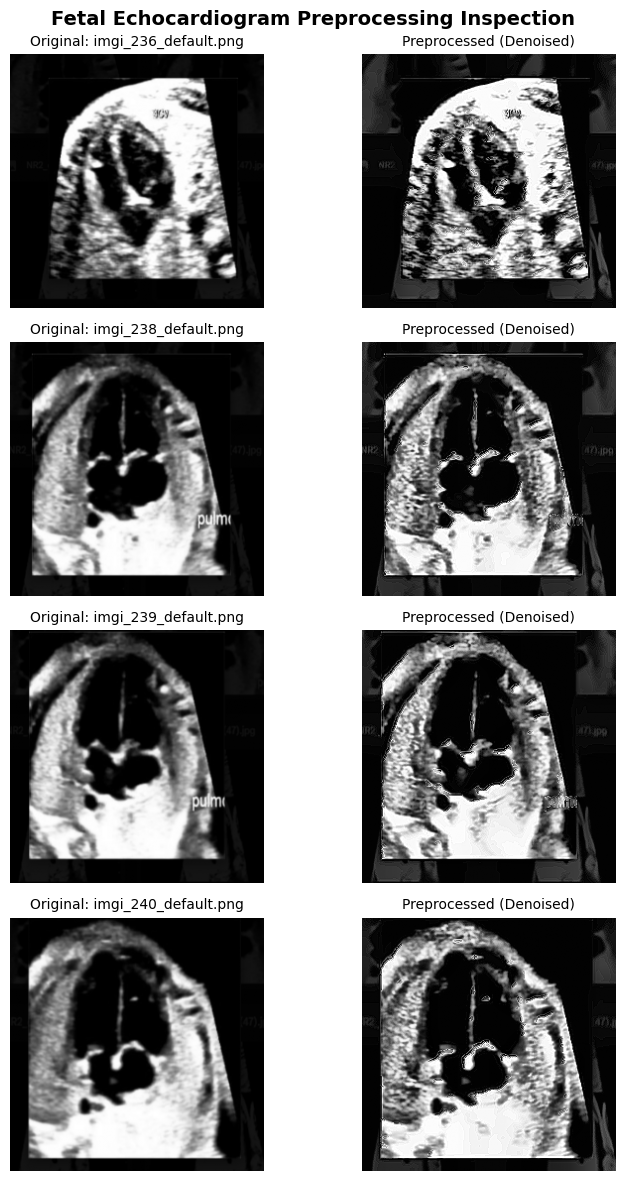

Successfully processed and saved 47 images!


In [3]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_save_dataset(data_dir, output_folder_name="preprocessed_chd_data", num_samples_to_show=4):
    output_dir = os.path.join(data_dir, output_folder_name)
    os.makedirs(output_dir, exist_ok=True)

    # Valid image extensions (case-insensitive)
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

    # Find all images recursively across subfolders, ignoring the output folder
    image_paths = []
    for root, _, files in os.walk(data_dir):
        if output_folder_name in root:
            continue  # Skip output subfolder if running re-executions
        for file in files:
            if file.lower().endswith(valid_exts):
                image_paths.append(os.path.join(root, file))

    print(f"Found {len(image_paths)} images in: {data_dir}")
    print(f"Saving preprocessed images to: {output_dir}\n")

    if len(image_paths) == 0:
        print("⚠️ Still found 0 images! Double check your folder structure or path.")
        return

    raw_samples, prep_samples, sample_names = [], [], []

    for i, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)

        raw_img, prep_img = preprocess_fetal_echo_hd(img_path)
        if raw_img is None:
            continue

        # Preserve subfolder structure or save directly
        save_path = os.path.join(output_dir, f"prep_{filename}")
        cv2.imwrite(save_path, prep_img)

        if len(raw_samples) < num_samples_to_show:
            raw_samples.append(raw_img)
            prep_samples.append(prep_img)
            sample_names.append(filename)

    # --- Display Grid ---
    n = len(raw_samples)
    if n > 0:
        fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))
        if n == 1:
            axes = np.expand_dims(axes, axis=0)

        fig.suptitle("Fetal Echocardiogram Preprocessing Inspection", fontsize=14, fontweight='bold')

        for idx in range(n):
            axes[idx, 0].imshow(raw_samples[idx], cmap='gray')
            axes[idx, 0].set_title(f"Original: {sample_names[idx]}", fontsize=10)
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(prep_samples[idx], cmap='gray')
            axes[idx, 1].set_title(f"Preprocessed (Denoised)", fontsize=10)
            axes[idx, 1].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"Successfully processed and saved {len(image_paths)} images!")

# --- EXECUTION ---
DATA_DIR = "/content/drive/MyDrive/chd_data"
process_and_save_dataset(data_dir=DATA_DIR, num_samples_to_show=4)

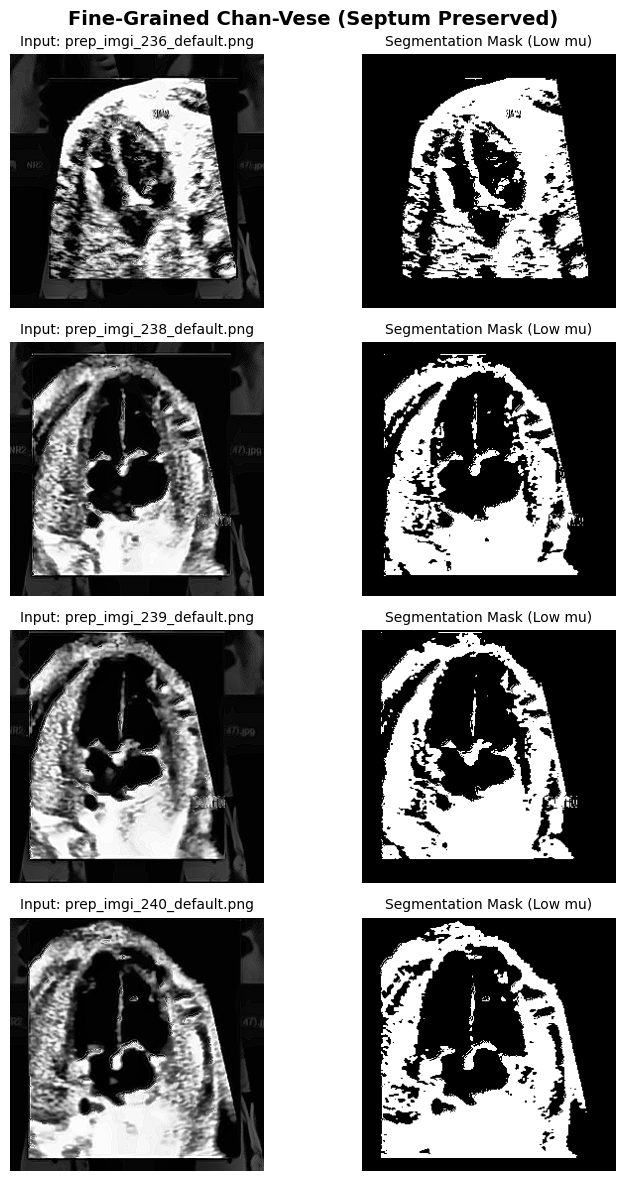

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import chan_vese

def segment_fetal_heart_fine(img_prep):
    """
    Chan-Vese parameter tuning specifically calibrated to detect
    thin anatomical borders like the intervendricular septum.
    """
    # Normalize image to [0, 1]
    img_float = img_prep.astype(np.float32) / 255.0

    # 1. Lower 'mu' significantly (0.02) -> allows boundary to enter thin structures
    # 2. Set 'lambda1' and 'lambda2' to balance dark vs light region energy
    cv_mask = chan_vese(
        img_float,
        mu=0.02,          # CRITICAL FIX: Low penalty for perimeter length
        lambda1=1.0,
        lambda2=1.5,      # Slight bias toward detecting bright tissue boundaries
        tol=1e-4,
        max_num_iter=250, # Slightly more iterations to converge inside thin walls
        dt=0.5,
        init_level_set="checkerboard"
    )

    # Convert boolean mask to uint8 (255 = tissue, 0 = chambers)
    mask_uint8 = (cv_mask * 255).astype(np.uint8)

    return mask_uint8

def run_fine_segmentation(prep_data_dir, output_folder_name="segmented_chd_masks_v2", num_samples_to_show=4):
    output_dir = os.path.join(prep_data_dir, output_folder_name)
    os.makedirs(output_dir, exist_ok=True)

    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp')
    image_paths = []
    for root, _, files in os.walk(prep_data_dir):
        if output_folder_name in root:
            continue
        for file in files:
            if file.lower().endswith(valid_exts):
                image_paths.append(os.path.join(root, file))

    prep_samples, mask_samples, sample_names = [], [], []

    for i, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)
        img_prep = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_prep is None:
            continue

        # Run fine-grained Chan-Vese
        mask = segment_fetal_heart_fine(img_prep)

        # Save output
        save_path = os.path.join(output_dir, f"mask_{filename}")
        cv2.imwrite(save_path, mask)

        if len(prep_samples) < num_samples_to_show:
            prep_samples.append(img_prep)
            mask_samples.append(mask)
            sample_names.append(filename)

    # --- Display Grid ---
    n = len(prep_samples)
    if n > 0:
        fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))
        if n == 1:
            axes = np.expand_dims(axes, axis=0)

        fig.suptitle("Fine-Grained Chan-Vese (Septum Preserved)", fontsize=14, fontweight='bold')

        for idx in range(n):
            axes[idx, 0].imshow(prep_samples[idx], cmap='gray')
            axes[idx, 0].set_title(f"Input: {sample_names[idx]}", fontsize=10)
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(mask_samples[idx], cmap='gray')
            axes[idx, 1].set_title("Segmentation Mask (Low mu)", fontsize=10)
            axes[idx, 1].axis('off')

        plt.tight_layout()
        plt.show()

# --- EXECUTION ---
PREP_DIR = "/content/drive/MyDrive/chd_data/preprocessed_chd_data"
run_fine_segmentation(prep_data_dir=PREP_DIR, num_samples_to_show=4)

In [1]:
import os
import glob
import cv2
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

def extract_dense_sift(img, step_size=8):
    """
    Extracts SIFT descriptors on a dense grid rather than just corner keypoints.
    This guarantees uniform coverage across cardiac walls and chambers.
    """
    sift = cv2.SIFT_create()

    # Create a dense grid of keypoints
    keypoints = [
        cv2.KeyPoint(float(x), float(y), step_size)
        for y in range(0, img.shape[0], step_size)
        for x in range(0, img.shape[1], step_size)
    ]

    keypoints, descriptors = sift.compute(img, keypoints)
    return keypoints, descriptors

def build_sift_qml_pipeline(data_dir, num_qml_features=6, num_visual_words=16):
    """
    1. Loads preprocessed images.
    2. Collects all SIFT descriptors across the dataset.
    3. Builds a K-Means visual vocabulary (BoVW).
    4. Transforms each image into a normalized 6D QML-ready vector via PCA.
    """
    # 1. Gather image paths
    extensions = ('*.png', '*.jpg', '*.jpeg', '*.bmp')
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(data_dir, ext)))
    image_paths.sort()

    print(f"Found {len(image_paths)} preprocessed images.")

    all_descriptors = []
    image_descriptors_list = []
    valid_paths = []

    # 2. Extract SIFT descriptors for all images
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        _, des = extract_dense_sift(img, step_size=8)

        if des is not None and len(des) > 0:
            all_descriptors.append(des)
            image_descriptors_list.append(des)
            valid_paths.append(path)

    if not all_descriptors:
        raise ValueError("No SIFT descriptors were extracted. Check image directory.")

    all_descriptors_stacked = np.vstack(all_descriptors)
    print(f"Total SIFT keypoints extracted across dataset: {all_descriptors_stacked.shape[0]}")

    # 3. Construct Visual Vocabulary via K-Means Clustering
    print(f"Clustering keypoints into {num_visual_words} visual words...")
    kmeans = KMeans(n_clusters=num_visual_words, random_state=42, n_init=10)
    kmeans.fit(all_descriptors_stacked)

    # 4. Convert each image into a Bag-of-Visual-Words Histogram
    bovw_histograms = []
    for des in image_descriptors_list:
        words = kmeans.predict(des)
        hist, _ = np.histogram(words, bins=range(num_visual_words + 1), density=True)
        bovw_histograms.append(hist)

    bovw_matrix = np.array(bovw_histograms)
    print(f"Raw BoVW Histogram Matrix Shape: {bovw_matrix.shape}")

    # 5. Dimensionality Reduction via PCA to match target QML qubit size (e.g., 6)
    pca = PCA(n_components=num_qml_features, random_state=42)
    features_pca = pca.fit_transform(bovw_matrix)
    print(f"PCA Variance Retained: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

    # 6. Scaling Features to [0, pi] for Quantum Rotational Encoding
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    qml_feature_matrix = scaler.fit_transform(features_pca)

    return qml_feature_matrix, valid_paths

# --- EXECUTION ---
DATA_DIR = "/content/drive/MyDrive/chd_data/preprocessed_chd_data"

X_qml, img_paths = build_sift_qml_pipeline(
    data_dir=DATA_DIR,
    num_qml_features=6,    # Number of features / qubits for your QML circuit
    num_visual_words=16    # Size of SIFT codebook
)

# Save feature matrix for ML/QML models
output_save_path = os.path.join(DATA_DIR, "sift_qml_features.npy")
np.save(output_save_path, X_qml)

print(f"\nFinal QML Feature Matrix Shape: {X_qml.shape}")
print(f"Saved QML Features to: {output_save_path}")
print("\nFirst Sample Feature Vector (Scaled [0, pi]):\n", X_qml[0])

Found 47 preprocessed images.
Total SIFT keypoints extracted across dataset: 48128
Clustering keypoints into 16 visual words...
Raw BoVW Histogram Matrix Shape: (47, 16)
PCA Variance Retained: 94.72%

Final QML Feature Matrix Shape: (47, 6)
Saved QML Features to: /content/drive/MyDrive/chd_data/preprocessed_chd_data/sift_qml_features.npy

First Sample Feature Vector (Scaled [0, pi]):
 [0.69085502 0.53273823 0.0692572  0.59588157 0.         0.76828398]


In [2]:
import numpy as np
import os

# Define the directory where the features were saved
DATA_DIR = "/content/drive/MyDrive/chd_data/preprocessed_chd_data"
output_save_path = os.path.join(DATA_DIR, "sift_qml_features.npy")

# Load the array using the correct path
features = np.load(output_save_path)

# Inspect its properties and data
print("Shape:", features.shape)
print("Data Type:", features.dtype)
print("First 5 rows:\n", features[:5, :])

Shape: (47, 6)
Data Type: float64
First 5 rows:
 [[0.69085502 0.53273823 0.0692572  0.59588157 0.         0.76828398]
 [0.47547675 0.10154166 0.78710008 0.41006862 1.0666977  0.76229306]
 [0.28630943 0.3464462  0.69347142 1.14476353 0.44640741 0.89070747]
 [0.59708314 0.1319614  0.89993574 1.00670554 2.03790294 2.04836602]
 [0.17104236 0.19953794 1.04515137 1.30699959 2.16078642 0.93980139]]


In [2]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Reconstruct img_paths as they were not saved alongside X_qml
DATA_DIR_PREPROCESSED = "/content/drive/MyDrive/chd_data/preprocessed_chd_data"
extensions = ('*.png', '*.jpg', '*.jpeg', '*.bmp')
image_paths = []
for ext in extensions:
    image_paths.extend(glob.glob(os.path.join(DATA_DIR_PREPROCESSED, ext)))
image_paths.sort()

# Extract original filenames from preprocessed paths to match with labels.csv
# e.g., 'prep_img_236_default.png' -> 'img_236_default.png'
original_filenames = [os.path.basename(path).replace("prep_", "") for path in image_paths]

# Assuming labels are in a CSV in the main data directory
MAIN_DATA_DIR = "/content/drive/MyDrive/chd_data"
# Replace 'labels.csv' and column names ('filename', 'label') if yours are different
try:
    labels_df = pd.read_csv(os.path.join(MAIN_DATA_DIR, "labels.csv"))
    print("Labels file loaded successfully.")
except FileNotFoundError:
    print(f"Error: 'labels.csv' not found in {MAIN_DATA_DIR}. Please create this file with image filenames and labels.")
    labels_df = None

if labels_df is not None:
    # Create a DataFrame from the reconstructed paths and their corresponding feature index
    features_aligned_df = pd.DataFrame({'original_filename': original_filenames, 'feature_index': range(len(features))})

    # Merge with the loaded labels DataFrame
    # Assuming labels_df has 'filename' and 'label' columns
    merged_data = pd.merge(features_aligned_df, labels_df, left_on='original_filename', right_on='filename', how='left')

    # Ensure the merged data is sorted by 'feature_index' to align with the 'features' numpy array
    merged_data = merged_data.sort_values('feature_index')

    # Extract labels (y)
    # Drop rows where labels might be missing if a filename in features_aligned_df wasn't in labels_df
    merged_data_cleaned = merged_data.dropna(subset=['label'])

    if len(merged_data_cleaned) < len(features):
        print(f"Warning: {len(features) - len(merged_data_cleaned)} labels could not be found for the extracted features. These features will be excluded.")

    # Align features (X) with the cleaned labels
    X = features[merged_data_cleaned['feature_index'].values]
    y = merged_data_cleaned['label'].values

    # Split data into training and testing sets
    # Using stratify=y for classification tasks to maintain class proportions
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nData Split Summary:")
    print(f"Total samples after label alignment: {len(X)}")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("Cannot proceed with data splitting without labels.")

Error: 'labels.csv' not found in /content/drive/MyDrive/chd_data. Please create this file with image filenames and labels.
Cannot proceed with data splitting without labels.


With your data now split into training and testing sets, you can proceed to train a classification model. Given that these features (`X_train`, `X_test`) are scaled to `[0, \pi]` for quantum rotational encoding, you could explore building a Quantum Machine Learning (QML) classifier. Alternatively, you can use traditional classical machine learning models like SVMs, Random Forests, or neural networks.

### Example: Building a Basic QML Classifier (Conceptual steps)

For a QML approach, you would typically:

1.  **Map Classical Data to Quantum States:** Encode `X_train` into quantum feature maps using quantum circuits (e.g., `qiskit.circuit.QuantumCircuit` or `pennylane`).
2.  **Design a Variational Quantum Circuit (VQC):** Build a parameterized quantum circuit as your model.
3.  **Define a Cost Function:** Measure the performance of your QML model (e.g., using cross-entropy).
4.  **Optimize the Circuit Parameters:** Use a classical optimizer to minimize the cost function, effectively training your quantum model.
5.  **Evaluate:** Test your trained QML model on `X_test`.

### Example: Building a Classical Classifier (e.g., SVM)

For a classical approach, you could:

1.  **Import a Classifier:** From `sklearn`, import a classifier like `SVC`.
2.  **Train the Model:** Fit the model to `X_train` and `y_train`.
3.  **Make Predictions:** Predict on `X_test`.
4.  **Evaluate:** Calculate metrics like accuracy, precision, recall using `y_test` and the predictions.

What kind of model would you like to explore next?